In [103]:
import os
from dotenv import load_dotenv

load_dotenv("config.env", override=True)

print("Groq key loaded:", os.getenv("GROQ_API_KEY") is not None)
print("Tavily key loaded:", os.getenv("TAVILY_API_KEY") is not None)

Groq key loaded: True
Tavily key loaded: True


In [104]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

print("Groq model configured successfully!")

Groq model configured successfully!


In [105]:
response = llm.invoke(
    "Explain diabetes in one simple sentence."
)

print(response.content)

Diabetes is a condition where the body can’t properly regulate blood sugar because it either doesn’t make enough insulin or can’t use the insulin it does produce.


In [106]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily configured successfully!")

Tavily configured successfully!


In [107]:
search_response = tavily_search.invoke(
    "diabetes symptoms causes prevention treatment"
)

print(search_response)

{'query': 'diabetes symptoms causes prevention treatment', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.manipalhospitals.com/millersroad/blog/diabetes-guide-symptoms-causes-treatment-options-prevention-tips', 'title': 'Symptoms, Causes, Treatment Options & Prevention Tips', 'content': '### 1800 102 5555\n\n  Diabetes Guide: Symptoms, Causes, Treatment Options & Prevention Tips\n\nEnglish\n\n8.png)\n\n##### Department of Diabetic Care Clinic\n\nBook Appointment\n\n## Subscribe to our blogs\n\n8.png)\n\n##### Department of Diabetic Care Clinic\n\nBook Appointment\n\n# Diabetes Guide: Symptoms, Causes, Treatment Options & Prevention Tips\n\n##### Posted On: Dec 08, 2025\n\n##### blogs read 7 Min Read\n\nDiabetes Guide: Symptoms, Causes, Treatment Options & Prevention Tips [...] Diabetes Guide: Symptoms, Causes, Treatment Options & Prevention Tips\n\n  Book Appointments & Health Checkup Packages\n Access Lab Reports\n\n Diabetes Guide: Symptom

In [108]:
from typing import TypedDict


class HealthBotState(TypedDict):
    topic: str
    search_results: list
    summary: str
    sources: list
    quiz_question: str
    patient_answer: str
    grade: str
    feedback: str
    continue_session: bool


print("HealthBotState created successfully!")

HealthBotState created successfully!


In [109]:
def get_topic(state: HealthBotState):
    topic = input("Enter a health topic: ")

    return {
        **state,
        "topic": topic
    }


In [110]:
def search_health_information(state: HealthBotState):
    topic = state["topic"]

    results = tavily_search.invoke(
        f"{topic} symptoms causes prevention treatment"
    )

    sources = [
        {
            "title": result.get("title", ""),
            "url": result.get("url", "")
        }
        for result in results.get("results", [])
    ]

    return {
        **state,
        "search_results": results,
        "sources": sources
    }


print("search_health_information node created successfully!")

search_health_information node created successfully!


In [111]:
def summarize_health_information(state: HealthBotState):

    search_data = state["search_results"]

    # Get the actual search results returned by Tavily
    results = search_data.get("results", [])

    context = "\n\n".join(
        [
            f"Title: {result.get('title', '')}\n"
            f"Content: {result.get('content', '')}"
            for result in results
        ]
    )

    prompt = f"""
You are a health education assistant.

Topic:
{state["topic"]}

Tavily Search Results:
{context}

Create a simple, clear and educational summary of the topic.

IMPORTANT RULES:
1. Use ONLY the information provided in the Tavily Search Results.
2. Do NOT use outside knowledge or information from any other source.
3. Write EXACTLY 3–4 paragraphs.
4. Each paragraph must contain complete sentences.
5. Do NOT use bullet points.
6. Do NOT use numbered lists.
7. Do NOT use headings inside the summary.
8. Do NOT use markdown formatting such as -, *, or #.
9. Separate each paragraph with a blank line.
10. Explain the topic in language that is easy for a general user to understand.
11. Do not provide a diagnosis or personalized medical advice.
12. Do not say that information is missing when the Tavily Search Results contain relevant information.
13. Include only facts that are supported by the Tavily Search Results.

The 3–4 paragraphs should naturally explain the important information
available in the search results, such as what the condition is, symptoms,
causes, prevention, treatment, or management, depending on what information
is actually available in the results.

Return ONLY the 3–4 paragraph summary.
Do not return JSON.
Do not return bullet points.
Do not return a list.
"""

    response = llm.invoke(prompt)

    return {
        **state,
        "summary": response.content
    }


print("summarize_health_information node created successfully!")

summarize_health_information node created successfully!


In [112]:
def present_summary(state: HealthBotState):

    print("\n" + "=" * 60)
    print("HEALTH INFORMATION")
    print("=" * 60)

    print(state["summary"])

    print("\n" + "-" * 60)
    print("SOURCES")
    print("-" * 60)

    for i, source in enumerate(state["sources"], start=1):
        print(f"{i}. {source['title']}")
        print(f"   {source['url']}")

    print("=" * 60)

    return state


print("present_summary node created successfully!")

present_summary node created successfully!


In [113]:
def create_quiz_question(state: HealthBotState):

    prompt = f"""
You are creating a short-answer quiz question for a health education assistant.

Use ONLY the information in the summary below.

Summary:
{state["summary"]}

IMPORTANT RULES:
1. Create ONE descriptive question.
2. The question must be answerable using ONLY the summary.
3. Do not use outside knowledge.
4. The question should require a short written answer.
5. Also provide the expected answer based only on the summary.

Format:

Question: ...

Expected Answer: ...

Return plain text only.
Do not return JSON.
"""

    response = llm.invoke(prompt)

    return {
        "quiz_question": response.content
    }


print("Descriptive quiz question node created successfully!")


Descriptive quiz question node created successfully!


In [114]:
def get_patient_answer(state: HealthBotState):

    print("\n" + "=" * 60)
    print("QUIZ QUESTION")
    print("=" * 60)
    print(state["quiz_question"])
    print("=" * 60)

    answer = input("\nEnter your answer: ")

    return {
        **state,
        "patient_answer": answer.strip()
    }


print("get_patient_answer node created successfully!")

get_patient_answer node created successfully!


In [115]:
def grade_patient_answer(state: HealthBotState):

    prompt = f"""
You are grading a student's descriptive answer to a health education quiz.

Use ONLY the summary below as the source of truth.

Summary:
{state["summary"]}

Quiz:
{state["quiz_question"]}

Student's Answer:
{state["patient_answer"]}

IMPORTANT RULES:
1. Use ONLY the information in the summary.
2. Do NOT use outside knowledge.
3. Compare the student's answer with the expected answer.
4. Give exactly one letter grade: A, B, C, or D.
5. Give brief feedback explaining why the grade was given.
6. Give credit when the student's answer correctly expresses the key
   information from the expected answer, even if the wording is different.

Use EXACTLY this format:

Grade: A

Feedback: Your explanation here.

Do not add anything else.
"""

    response = llm.invoke(prompt)

    grade_text = response.content.strip()

    return {
        **state,
        "grade": grade_text
    }


print("Descriptive answer grading node created successfully!")

Descriptive answer grading node created successfully!


In [116]:
def present_grade(state: HealthBotState):

    print("\n" + "=" * 60)
    print("QUIZ RESULT")
    print("=" * 60)

    print(state["grade"])

    print("=" * 60)

    return state


print("present_grade node created successfully!")

present_grade node created successfully!


In [117]:
def ask_continue(state: HealthBotState):
    answer = input(
        "\nWould you like to learn about another health topic? (yes/no): "
    )

    continue_session = answer.strip().lower() in ["yes", "y"]

    return {
        **state,
        "continue_session": continue_session
    }


print("ask_continue node created successfully!")

ask_continue node created successfully!


In [118]:
def reset_state(state: HealthBotState):
    return {
        "topic": "",
        "search_results": [],
        "summary": "",
        "sources": [],
        "quiz_question": "",
        "patient_answer": "",
        "grade": "",
        "feedback": "",
        "continue_session": True
    }

In [119]:
from langgraph.graph import StateGraph, START, END

print("LangGraph imported successfully!")

LangGraph imported successfully!


In [120]:
builder = StateGraph(HealthBotState)

builder.add_node("get_topic", get_topic)
builder.add_node("search_health_information", search_health_information)
builder.add_node("summarize_health_information", summarize_health_information)
builder.add_node("present_summary", present_summary)
builder.add_node("create_quiz_question", create_quiz_question)
builder.add_node("get_patient_answer", get_patient_answer)
builder.add_node("grade_patient_answer", grade_patient_answer)
builder.add_node("present_grade", present_grade)
builder.add_node("ask_continue", ask_continue)
builder.add_node("reset_state", reset_state)

print("All HealthBot nodes added successfully!")

All HealthBot nodes added successfully!


In [121]:
builder.add_edge(START, "get_topic")
builder.add_edge("get_topic", "search_health_information")
builder.add_edge("search_health_information", "summarize_health_information")
builder.add_edge("summarize_health_information", "present_summary")
builder.add_edge("present_summary", "create_quiz_question")
builder.add_edge("create_quiz_question", "get_patient_answer")
builder.add_edge("get_patient_answer", "grade_patient_answer")
builder.add_edge("grade_patient_answer", "present_grade")
builder.add_edge("present_grade", "ask_continue")

print("HealthBot workflow edges added successfully!")

HealthBot workflow edges added successfully!


In [122]:
def continue_or_end(state: HealthBotState):

    if state["continue_session"]:
        return "yes"

    return "no"


builder.add_conditional_edges(
    "ask_continue",
    continue_or_end,
    {
        "yes": "reset_state",
        "no": END
    }
)

builder.add_edge("reset_state", "get_topic")

print("Conditional routing added successfully!")

Conditional routing added successfully!


In [123]:
healthbot = builder.compile()

print("HealthBot workflow compiled successfully!")

HealthBot workflow compiled successfully!


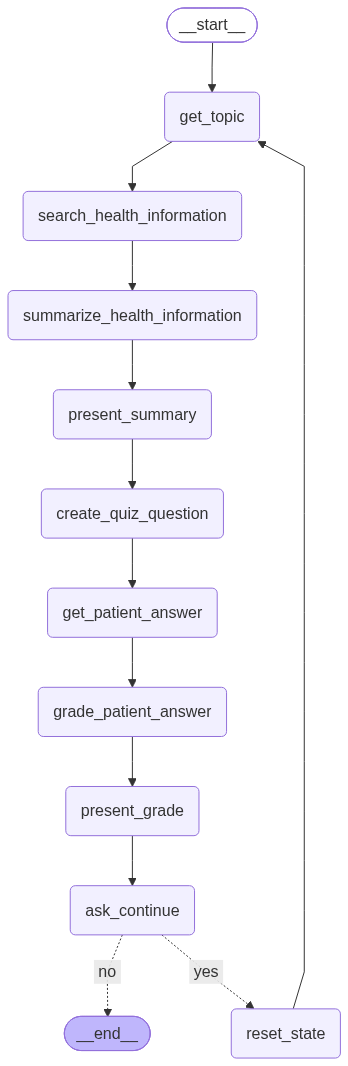

In [124]:
from IPython.display import Image, display

display(
    Image(
        healthbot.get_graph().draw_mermaid_png()
    )
)

In [127]:
initial_state = {
    "topic": "",
    "search_results": [],
    "summary": "",
    "quiz_question": "",
    "patient_answer": "",
    "grade": "",
    "feedback": "",
    "continue_session": False
}

result = healthbot.invoke(initial_state)




HEALTH INFORMATION
Diabetes is a condition in which the body has difficulty regulating blood sugar levels. There are several types, with type 2 diabetes being the most common, affecting about 90 % to 95 % of people who have the disease. Type 1 diabetes occurs when the immune system attacks insulin‑producing cells, while gestational diabetes develops during pregnancy and is identified by testing blood sugar between the 24th and 28th weeks. All types involve problems with insulin, the hormone that lets glucose from food enter cells for energy.

Typical symptoms of diabetes include increased thirst, frequent urination, unexplained weight loss, fatigue, and blurred vision. These signs can appear in both children and adults, and anyone who notices them should discuss the symptoms with a healthcare provider for proper evaluation.

The causes of diabetes differ by type. For type 1 diabetes, doctors do not yet know the exact triggers, but the result is a lack of insulin production. Type 2 dia